# Introduction

This notebook analyzes a synthetic dataset generated by the PaySim simulator, focusing on fraud detection in mobile money transactions. Fraud detection is a critical task for financial institutions as fraudulent activities can lead to significant monetary losses. This dataset simulates various types of mobile transactions and includes labels indicating whether a transaction was fraudulent. The goal is to explore and develop a model that can effectively detect fraudulent transactions based on transaction data.

Dataset Columns:

* step: A time unit representing one hour.
  
* type: Type of transaction: CASH-IN, CASH-OUT, DEBIT, PAYMENT, TRANSFER.
  
* amount: Transaction amount in local currency.
  
* nameOrig: Customer who initiated the transaction.
  
* oldbalanceOrg: Balance before the transaction (for the initiator).
  
* newbalanceOrig: Balance after the transaction (for the initiator).

* nameDest: Recipient of the transaction.

* oldbalanceDest: Balance before the transaction (for the recipient).

* newbalanceDest: Balance after the transaction (for the recipient).

* isFraud: Indicates if the transaction is fraudulent (1 = yes, 0 = no).
* isFlaggedFraud: Indicates if the transaction is flagged as fraud due to an unusually large transfer (transactions over 200,000).

The aim of this project is to use machine learning techniques to predict fraudulent transactions in this dataset based on the transaction characteristics.

# Importing Libraries

In [79]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import OneHotEncoder, StandardScaler, LabelEncoder
from imblearn.under_sampling import RandomUnderSampler
from lightgbm import LGBMClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, classification_report, roc_curve, auc, f1_score
from catboost import CatBoostClassifier


# Visualization Settings
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 4)

# Data Loading and Basic Exploration

In [3]:
raw_data = pd.read_csv("D:\Data science\Resumes\PS_20174392719_1491204439457_log.csv")

In [4]:
raw_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6362620 entries, 0 to 6362619
Data columns (total 11 columns):
 #   Column          Dtype  
---  ------          -----  
 0   step            int64  
 1   type            object 
 2   amount          float64
 3   nameOrig        object 
 4   oldbalanceOrg   float64
 5   newbalanceOrig  float64
 6   nameDest        object 
 7   oldbalanceDest  float64
 8   newbalanceDest  float64
 9   isFraud         int64  
 10  isFlaggedFraud  int64  
dtypes: float64(5), int64(3), object(3)
memory usage: 534.0+ MB


In [84]:
raw_data.isnull().sum()

step              0
type              0
amount            0
nameOrig          0
oldbalanceOrg     0
newbalanceOrig    0
nameDest          0
oldbalanceDest    0
newbalanceDest    0
isFraud           0
isFlaggedFraud    0
dtype: int64

In [4]:
summary = raw_data.describe()

In [5]:
summary.round(2)

,step,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
count,6362620.00,6362620.00,6362620.00,6362620.00,6.362620e+06,6.362620e+06,6362620.00,6362620.0
mean,243.40,179861.90,833883.10,855113.67,1.100702e+06,1.224996e+06,0.00,0.0
std,142.33,603858.23,2888242.67,2924048.50,3.399180e+06,3.674129e+06,0.04,0.0
min,1.00,0.00,0.00,0.00,0.000000e+00,0.000000e+00,0.00,0.0
25%,156.00,13389.57,0.00,0.00,0.000000e+00,0.000000e+00,0.00,0.0
50%,239.00,74871.94,14208.00,0.00,1.327057e+05,2.146614e+05,0.00,0.0
75%,335.00,208721.48,107315.18,144258.41,9.430367e+05,1.111909e+06,0.00,0.0
max,743.00,92445516.64,59585040.37,49585040.37,3.560159e+08,3.561793e+08,1.00,1.0


**Summary Insights:** 
* The transaction amounts have a wide range, from 0 to over 92 million, and there are outliers with exceptionally large amounts.
* Balances for both the initiating and receiving customers also show a wide range, from 0 to values exceeding 300 million

In [6]:
raw_data['isFraud'].value_counts(normalize=True) * 100

isFraud
0    99.870918
1     0.129082
Name: proportion, dtype: float64

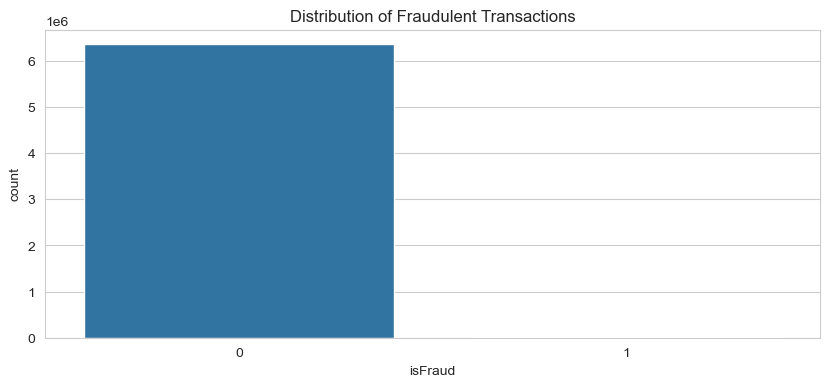

In [7]:
sns.countplot(x='isFraud', data=raw_data)
plt.title('Distribution of Fraudulent Transactions')
plt.show()

**Imbalanced Classes (Fraud vs. Non-Fraud):**
* The dataset is highly imbalanced, with only 0.13% of transactions marked as fraudulent (isFraud = 1), and the remaining 99.87% are non-fraudulent (isFraud = 0). This poses a significant challenge for modeling

In [8]:
raw_data[['amount', 'oldbalanceOrg', 'newbalanceOrig', 'oldbalanceDest', 'newbalanceDest']].skew()

amount            30.993949
oldbalanceOrg      5.249136
newbalanceOrig     5.176884
oldbalanceDest    19.921758
newbalanceDest    19.352302
dtype: float64

The transaction amounts (amount) and balances (oldbalanceOrg, newbalanceOrig, oldbalanceDest, newbalanceDest) have significant skewness, with the amount column having a skew of 30.99.

# EDA

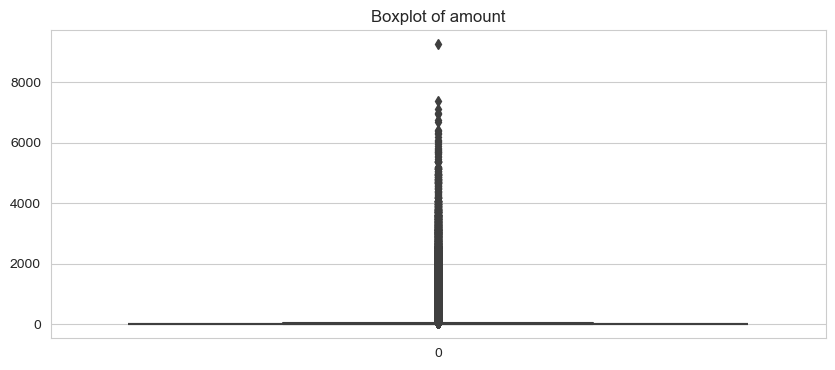

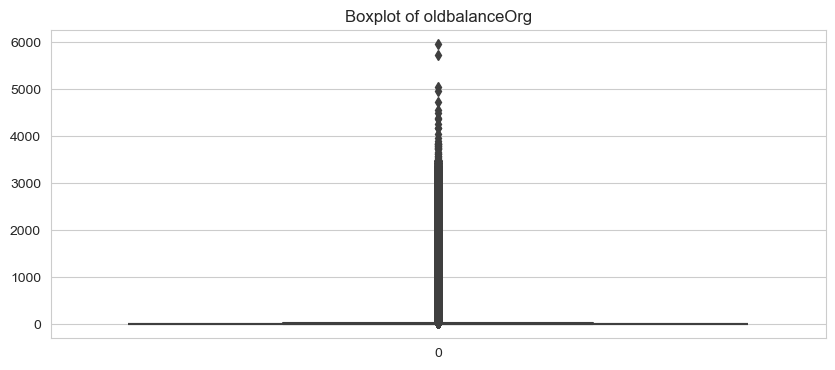

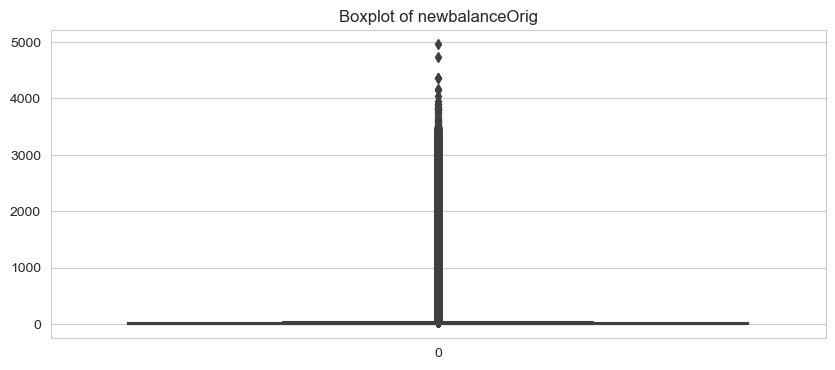

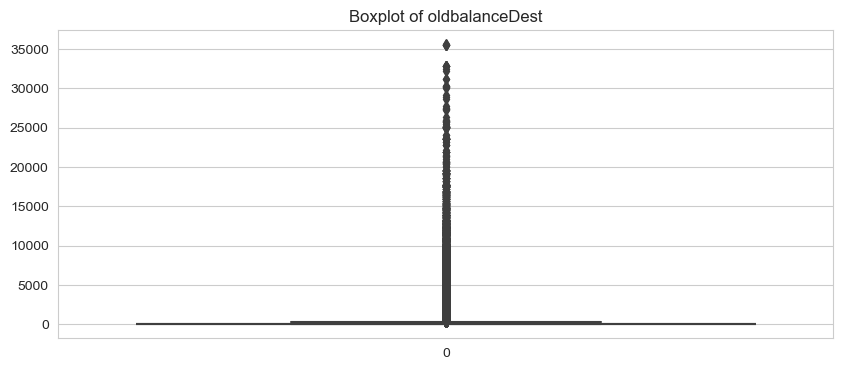

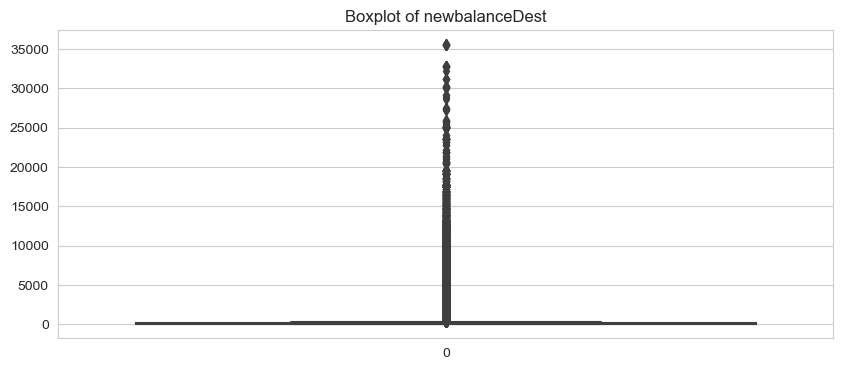

In [9]:
for column in ['amount', 'oldbalanceOrg', 'newbalanceOrig', 'oldbalanceDest', 'newbalanceDest']:
    sns.boxplot(raw_data[column]/10000)
    plt.title(f'Boxplot of {column}')
    plt.show()

C:\Users\saleh\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


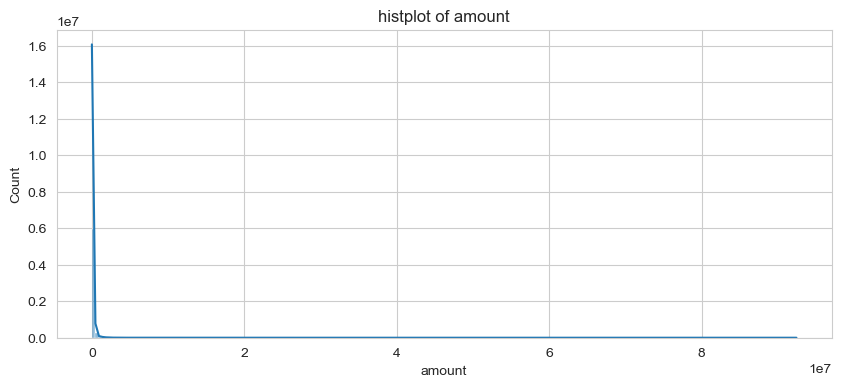

C:\Users\saleh\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


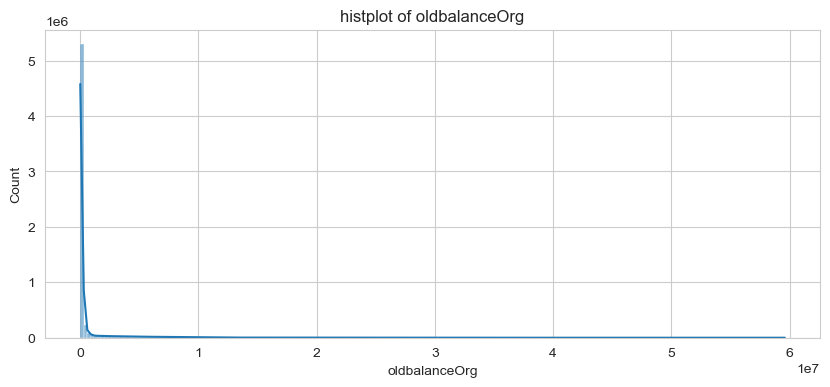

C:\Users\saleh\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


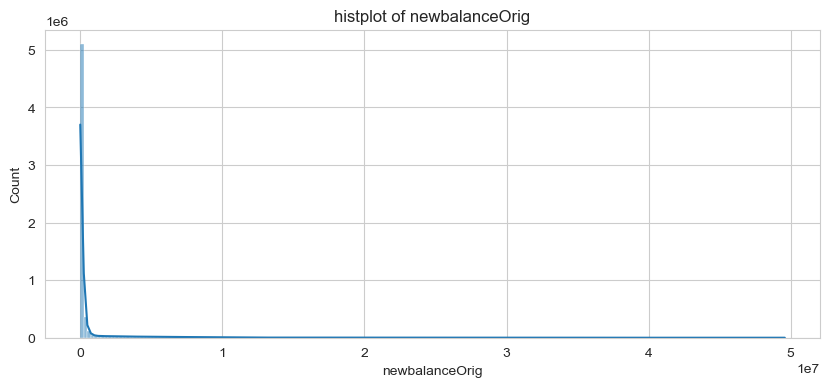

C:\Users\saleh\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


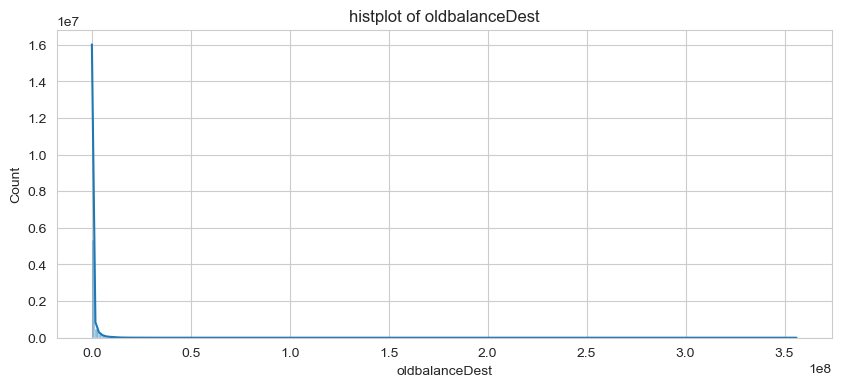

C:\Users\saleh\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


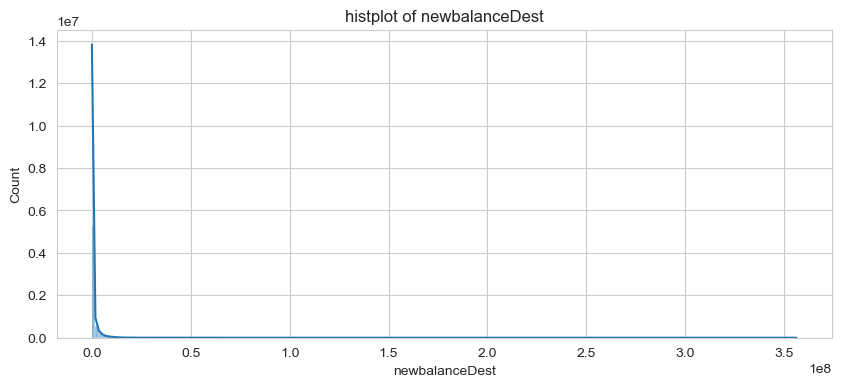

In [10]:
for column in ['amount', 'oldbalanceOrg', 'newbalanceOrig', 'oldbalanceDest', 'newbalanceDest']:
    sns.histplot(raw_data[column],bins = 200, kde =True)
    plt.title(f'histplot of {column}')
    plt.show()

In [11]:
data_transformed = raw_data[['amount', 'oldbalanceOrg', 'newbalanceOrig', 'oldbalanceDest', 'newbalanceDest']].apply(lambda x: np.log1p(x))

C:\Users\saleh\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


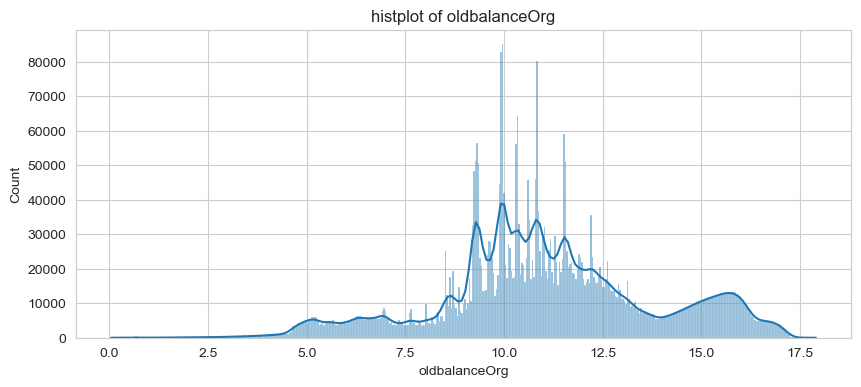

C:\Users\saleh\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


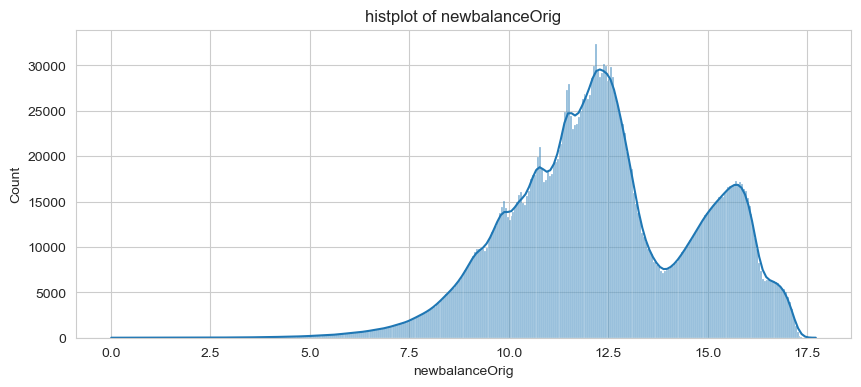

C:\Users\saleh\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


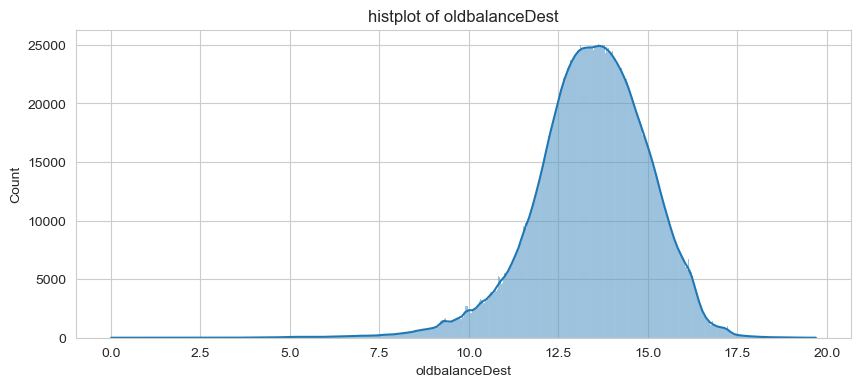

C:\Users\saleh\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


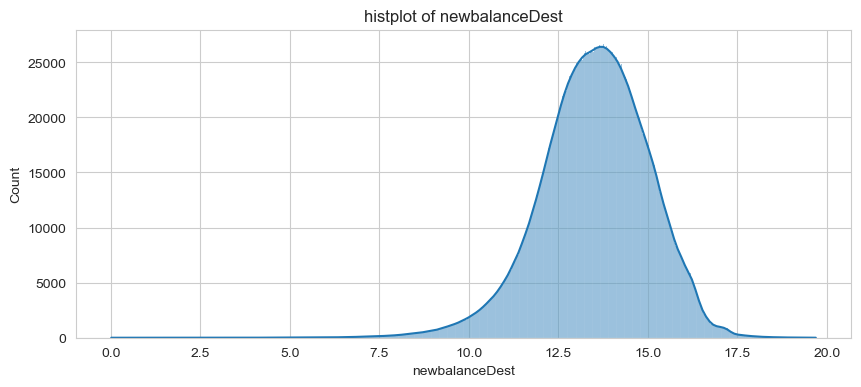

In [29]:
for column in ['oldbalanceOrg', 'newbalanceOrig', 'oldbalanceDest', 'newbalanceDest']:
    sns.histplot(data_transformed[data_transformed[column] > 0][column], kde =True)
    plt.title(f'histplot of {column}')
    plt.show()

In [13]:
Q1 = raw_data[['amount', 'oldbalanceOrg', 'newbalanceOrig', 'oldbalanceDest', 'newbalanceDest']].quantile(0.25)
Q3 = raw_data[['amount', 'oldbalanceOrg', 'newbalanceOrig', 'oldbalanceDest', 'newbalanceDest']].quantile(0.75)
IQR = Q3 - Q1

# Define extreme outliers as 3 × IQR
lower_bound = Q1 - 3 * IQR
upper_bound = Q3 + 3 * IQR

In [14]:
# Iterate over the relevant columns
for col in ['amount', 'oldbalanceOrg', 'newbalanceOrig', 'oldbalanceDest', 'newbalanceDest']:
    # Compare the current column with its specific lower and upper bounds
    outliers = (raw_data[col] < lower_bound[col]) | (raw_data[col] > upper_bound[col])
    
    # Count the number of outliers in the current column
    outlier_count = outliers.sum()
    print(f"Outliers in column {col}: {outlier_count}")


Outliers in column amount: 174085
Outliers in column oldbalanceOrg: 929807
Outliers in column newbalanceOrig: 864681
Outliers in column oldbalanceDest: 474998
Outliers in column newbalanceDest: 425660


In [15]:
raw_data['type'] = raw_data['type'].astype(str)

Investigate Transaction Types vs. Fraud:

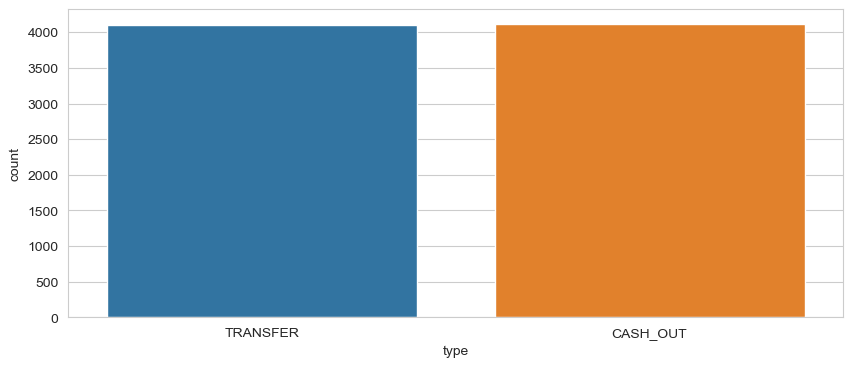

In [31]:
sns.countplot(x = 'type', data = raw_data[raw_data['isFraud']==1])
plt.show()

only two types of transaction  associated with fraud:
- Transfer
- Cash out

Checking amount distribution and skewness

C:\Users\saleh\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


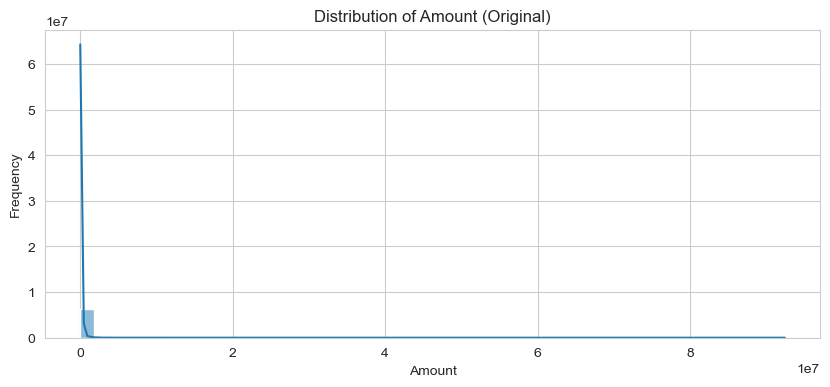

In [17]:
sns.histplot(raw_data['amount'], bins=50, kde=True)
plt.title('Distribution of Amount (Original)')
plt.xlabel('Amount')
plt.ylabel('Frequency')
plt.show()

C:\Users\saleh\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


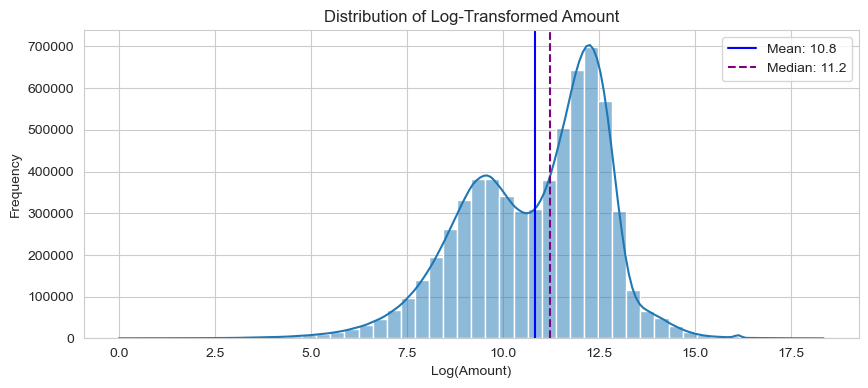

In [18]:
sns.histplot(data_transformed['amount'], bins=50, kde=True)
plt.title('Distribution of Log-Transformed Amount')
plt.xlabel('Log(Amount)')
plt.ylabel('Frequency')
mean_value = data_transformed['amount'].mean()
median_value = data_transformed['amount'].median()
plt.axvline(mean_value, color='blue', linestyle='-', label=f'Mean: {mean_value:.1f}')
plt.axvline(median_value, color='purple', linestyle='--', label=f'Median: {median_value:.1f}')
plt.legend()
plt.show()

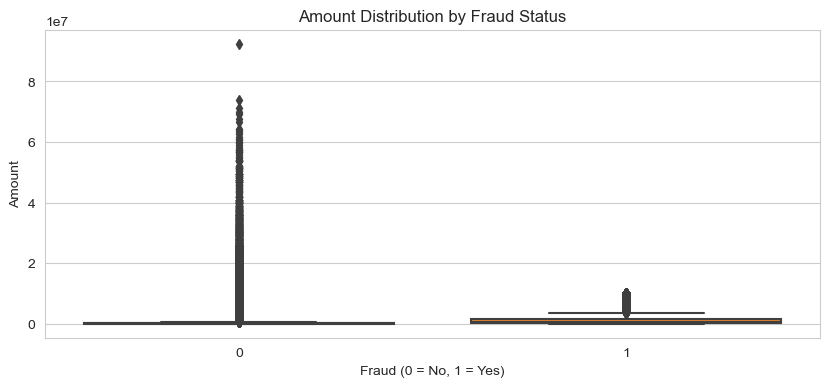

In [19]:
sns.boxplot(x='isFraud', y='amount', data=raw_data)
plt.title('Amount Distribution by Fraud Status')
plt.xlabel('Fraud (0 = No, 1 = Yes)')
plt.ylabel('Amount')
plt.show()

In [32]:
fraud_stats = raw_data[raw_data['isFraud'] == 1]['amount'].describe()/100
non_fraud_stats = raw_data[raw_data['isFraud'] == 0]['amount'].describe()/100
print("Summary Statistics for Amount (Fraud):")
print(fraud_stats)
print("\nSummary Statistics for Amount (Non-Fraud):")
print(non_fraud_stats)

Summary Statistics for Amount (Fraud):
count        82.130000
mean      14679.672991
std       24042.529472
min           0.000000
25%        1270.913300
50%        4414.234400
75%       15177.714800
max      100000.000000
Name: amount, dtype: float64

Summary Statistics for Amount (Non-Fraud):
count     63544.070000
mean       1781.970417
std        5962.369813
min           0.000100
25%         133.683950
50%         746.847200
75%        2083.647600
max      924455.166400
Name: amount, dtype: float64


In [33]:
summary = raw_data.groupby(['type', 'isFraud'])['amount'].describe()/100
print("Summary Statistics of Amount by Transaction Type and Fraud Status:")
print(summary)

Summary Statistics of Amount by Transaction Type and Fraud Status:
                     count          mean           std     min          25%  \
type     isFraud                                                              
CASH_IN  0        13992.84   1689.202420   1265.082553  0.0004   705.101825   
CASH_OUT 0        22333.84   1739.171558   1312.222410  0.0001   726.276900   
         1           41.16  14551.025860  23938.417858  0.0000  1254.644500   
DEBIT    0          414.32     54.836653    133.185355  0.0055    15.001800   
PAYMENT  0        21514.95    130.576047    125.564502  0.0002    43.838200   
TRANSFER 0         5288.12   9062.290078  18741.552588  0.0260  2165.707650   
         1           40.97  14808.916729  24148.903787  0.6380  1284.179600   

                         50%           75%          max  
type     isFraud                                         
CASH_IN  0        1434.27710   2398.990875   19152.6790  
CASH_OUT 0        1469.46560   2461.811800   28

* CASH_OUT and TRANSFER fraud transactions have large averages and are unevenly distributed.
* Some CASH_OUT fraud transactions have zero amounts, which needs checking.

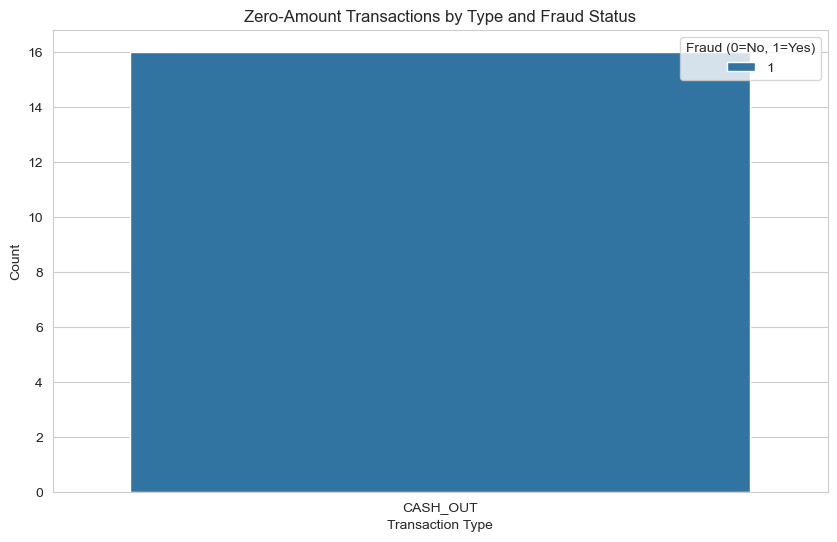

Zero-Amount Transactions Summary:
type      isFraud
CASH_OUT  1          16
dtype: int64


In [22]:
zero_amount = raw_data[raw_data['amount'] == 0]

# Plot zero-amount transactions by type and fraud status
plt.figure(figsize=(10, 6))
sns.countplot(x='type', hue='isFraud', data=zero_amount)
plt.title('Zero-Amount Transactions by Type and Fraud Status')
plt.xlabel('Transaction Type')
plt.ylabel('Count')
plt.legend(title='Fraud (0=No, 1=Yes)')
plt.show()

# Summary of zero-amount transactions
print("Zero-Amount Transactions Summary:")
print(zero_amount.groupby(['type', 'isFraud']).size())

In [35]:
raw_data['hour'] = raw_data['step'] % 24

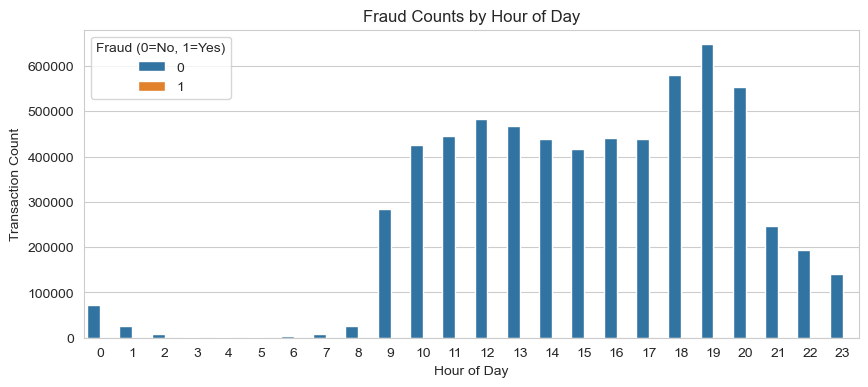

In [24]:
sns.countplot(x='hour', hue='isFraud', data=raw_data)
plt.title('Fraud Counts by Hour of Day')
plt.xlabel('Hour of Day')
plt.ylabel('Transaction Count')
plt.legend(title='Fraud (0=No, 1=Yes)')
plt.show()

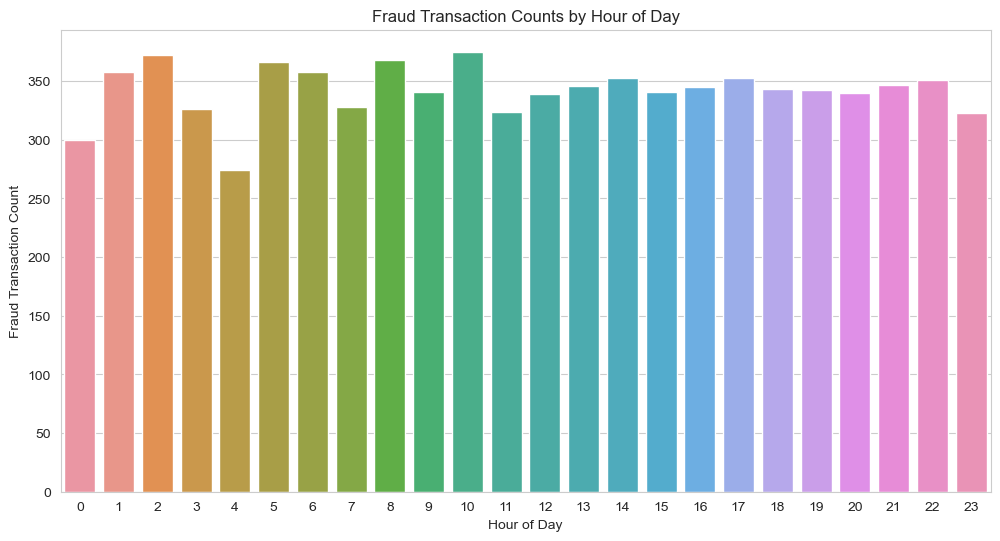

In [36]:
fraud_data = raw_data[raw_data['isFraud'] == 1]
plt.figure(figsize=(12, 6))
sns.countplot(x='hour', data=fraud_data)
plt.title('Fraud Transaction Counts by Hour of Day')
plt.xlabel('Hour of Day')
plt.ylabel('Fraud Transaction Count')
plt.show()

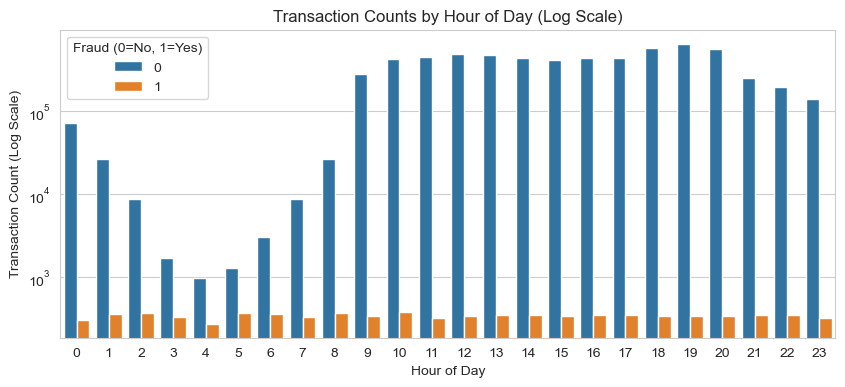

In [26]:
sns.countplot(x='hour', hue='isFraud', data=raw_data)
plt.title('Transaction Counts by Hour of Day (Log Scale)')
plt.xlabel('Hour of Day')
plt.ylabel('Transaction Count (Log Scale)')
plt.yscale('log')  # Log scale to make fraud visible
plt.legend(title='Fraud (0=No, 1=Yes)')
plt.show()

In [135]:
raw_data['isMerchant'] = raw_data['nameDest'].str.startswith('M').astype(int)

In [38]:
# Calculate fraud rates by isMerchant
fraud_rates = raw_data.groupby('isMerchant')['isFraud'].mean() * 100

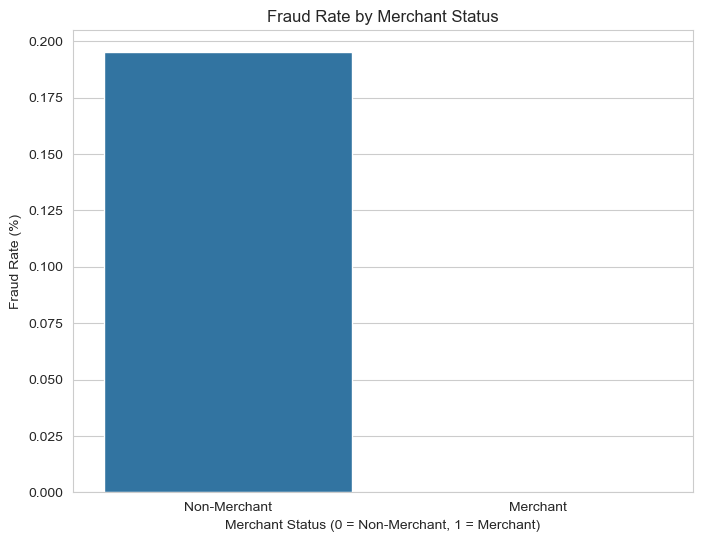

Fraud Rates by Merchant Status:
isMerchant
0    0.195031
1    0.000000
Name: isFraud, dtype: float64


In [39]:
# Plot fraud rates
plt.figure(figsize=(8, 6))
sns.barplot(x=fraud_rates.index, y=fraud_rates.values)
plt.title('Fraud Rate by Merchant Status')
plt.xlabel('Merchant Status (0 = Non-Merchant, 1 = Merchant)')
plt.ylabel('Fraud Rate (%)')
plt.xticks(ticks=[0, 1], labels=['Non-Merchant', 'Merchant'])
plt.show()

# Print fraud rates
print("Fraud Rates by Merchant Status:")
print(fraud_rates)

Observation: 
- Merchant transactions have a 0% fraud rate, while non-Merchant transactions have a low fraud rate of 0.195%.
- The isMerchant feature is highly predictive, as all fraud occurs in non-Merchant transactions, making it valuable for modeling.

**Observations from EDA:**
1. Transaction Types Associated with Fraud:
    * Fraud occurs only in two transaction types:
        * Transfer and Cash-Out are the only transaction types linked to fraudulent activities.
        * Payment and Cash-In do not exhibit any fraud, as confirmed by the data exploration.
2. Amount Distribution:
    * The amount column is highly skewed, with most transactions having small values but a few having extremely large amounts. After applying log-transformation, the distribution shows two peaks:
        * One peak likely represents small transactions (e.g., payments).
        * The other represents large transactions (e.g., transfers).
    * Fraudulent transactions tend to have much larger amounts than non-fraudulent ones, highlighting that large transaction amounts are a key indicator of fraud.
3. Fraud Distribution by Transaction Type:
    * Fraudulent transactions are linked to CASH_OUT and TRANSFER types, with these two transaction types exhibiting large averages and uneven distributions.
    * some CASH_OUT fraud transactions have zero amounts.
4. Fraud Rates by Merchant Status:
* Merchant transactions (where isMerchant = 1) have a 0% fraud rate, while non-Merchant transactions (where isMerchant = 0) have a fraud rate of about 0.195%.
* This makes the isMerchant feature highly predictive, as all fraudulent transactions occur in non-Merchant transactions. This feature will likely play a crucial role in fraud detection models.


**Key Insights:**
* Amount and transaction type (especially CASH_OUT and TRANSFER) are crucial predictors for identifying fraud.
* Handling transactions with zero amounts in fraud cases should be prioritized, as they might introduce noise or represent data errors.

# Data Preprocessing

In [136]:
data_processed = raw_data.copy()

In [137]:
data_processed.drop(['oldbalanceOrg', 'newbalanceOrig', 'oldbalanceDest', 'newbalanceDest'],axis = 1, inplace = True)

In [138]:
data_processed.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6362620 entries, 0 to 6362619
Data columns (total 8 columns):
 #   Column          Dtype  
---  ------          -----  
 0   step            int64  
 1   type            object 
 2   amount          float64
 3   nameOrig        object 
 4   nameDest        object 
 5   isFraud         int64  
 6   isFlaggedFraud  int64  
 7   isMerchant      int32  
dtypes: float64(1), int32(1), int64(3), object(3)
memory usage: 364.1+ MB


In [139]:
data_processed.head()

,step,type,amount,nameOrig,nameDest,isFraud,isFlaggedFraud,isMerchant
0,1,PAYMENT,9839.64,C1231006815,M1979787155,0,0,1
1,1,PAYMENT,1864.28,C1666544295,M2044282225,0,0,1
2,1,TRANSFER,181.00,C1305486145,C553264065,1,0,0
3,1,CASH_OUT,181.00,C840083671,C38997010,1,0,0
4,1,PAYMENT,11668.14,C2048537720,M1230701703,0,0,1


In [140]:
# Count transactions per nameOrig
data_processed['trans_freq_nameOrig'] = data_processed.groupby('nameOrig')['nameOrig'].transform('count')
# Count fraud transactions per nameOrig
data_processed['fraud_history_nameOrig'] = data_processed.groupby('nameOrig')['isFraud'].transform('sum')
# Subtract current transaction's isFraud to count only prior/other fraud
data_processed['fraud_history_nameOrig'] = data_processed['fraud_history_nameOrig'] - data_processed['isFraud']
# Calculate median amount for non-fraud transactions per type
non_fraud_medians = data_processed[data_processed['isFraud'] == 0].groupby('type')['amount'].median().to_dict()
# Create deviation feature
data_processed['amount_deviation'] = data_processed.apply(lambda x: x['amount'] - non_fraud_medians.get(x['type'], 0), axis=1)
data_processed['hour'] = data_processed['step'] % 24
data_processed['high_risk_hour'] = data_processed['hour'].apply(lambda x: 1 if 0 <= x <= 6 else 0)
# Calculate flagged fraud ratio per type
flagged_ratio = data_processed.groupby('type')['isFlaggedFraud'].mean().to_dict()
# Map ratio to each transaction
data_processed['flagged_fraud_ratio'] = data_processed['type'].map(flagged_ratio)
# Create zero-amount flag
data_processed['isZeroAmount'] = (data_processed['amount'] == 0).astype(int)

In [141]:
data_processed.head()

,step,type,amount,nameOrig,nameDest,isFraud,isFlaggedFraud,isMerchant,trans_freq_nameOrig,fraud_history_nameOrig,amount_deviation,hour,high_risk_hour,flagged_fraud_ratio,isZeroAmount
0,1,PAYMENT,9839.64,C1231006815,M1979787155,0,0,1,1,0,357.45,1,1,0.00000,0
1,1,PAYMENT,1864.28,C1666544295,M2044282225,0,0,1,1,0,-7617.91,1,1,0.00000,0
2,1,TRANSFER,181.00,C1305486145,C553264065,1,0,0,1,0,-486340.91,1,1,0.00003,0
3,1,CASH_OUT,181.00,C840083671,C38997010,1,0,0,1,0,-146765.56,1,1,0.00000,0
4,1,PAYMENT,11668.14,C2048537720,M1230701703,0,0,1,1,0,2185.95,1,1,0.00000,0


In [142]:
data_processed['log_amount'] = np.log1p(data_processed['amount'])

In [143]:
le =  LabelEncoder()

In [144]:
data_processed['type'] = le.fit_transform(data_processed[['type']])

C:\Users\saleh\AppData\Roaming\Python\Python311\site-packages\sklearn\preprocessing\_label.py:110: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


In [145]:
data_processed.drop(['nameOrig','nameDest','amount'],axis = 1 , inplace = True)

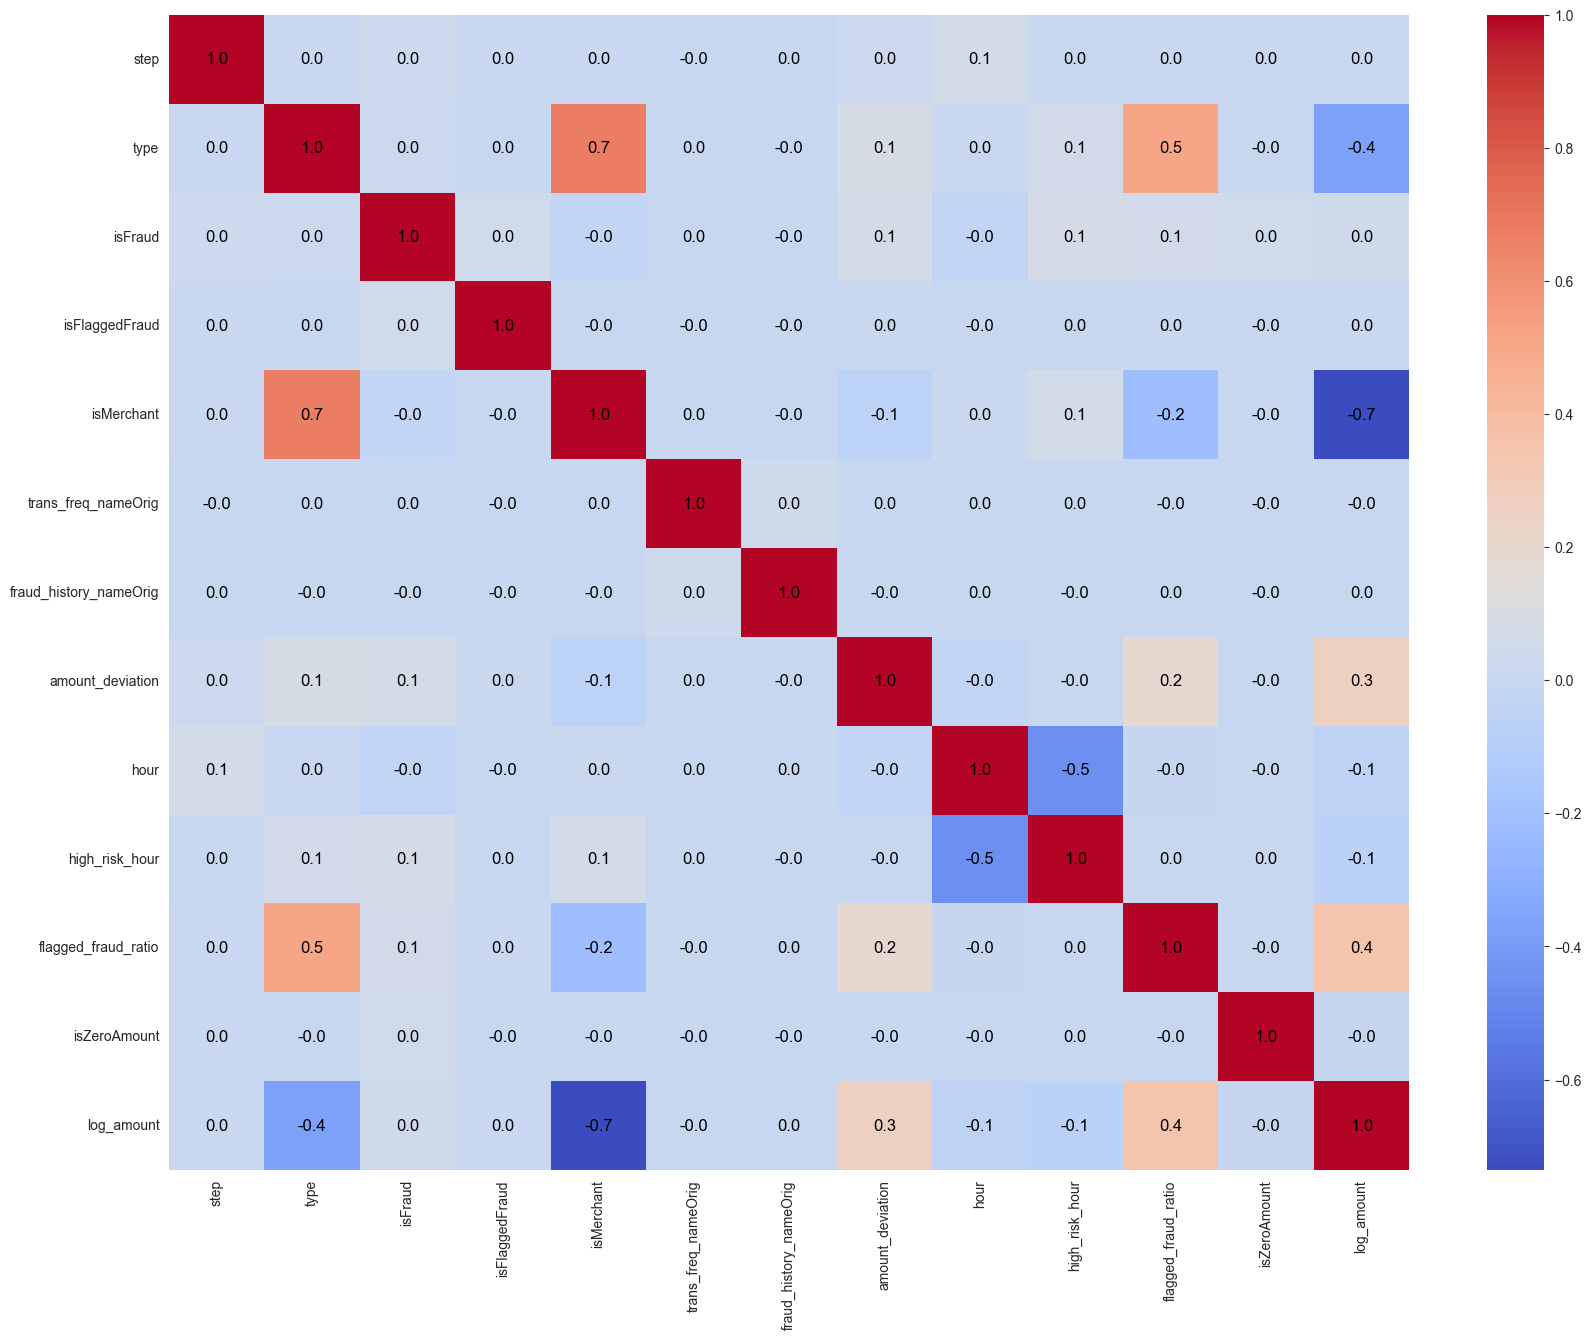

In [146]:
plt.figure(figsize=(20, 15))
corr = data_processed.corr()  # Scaling correlation values
sns.heatmap(corr, annot=True, fmt=".1f", cmap='coolwarm', annot_kws={'size': 12, 'color': 'black'})  # Black text for contrast
plt.show()

In [147]:
data_processed.corr()

,step,type,isFraud,isFlaggedFraud,isMerchant,trans_freq_nameOrig,fraud_history_nameOrig,amount_deviation,hour,high_risk_hour,flagged_fraud_ratio,isZeroAmount,log_amount
step,1.000000,0.006635,0.031578,0.003277,0.004926,-0.000830,0.000121,0.023257,0.061729,0.002544,0.006925,0.003277,0.007377
type,0.006635,1.000000,0.020833,0.002685,0.680754,0.000051,-0.000444,0.085731,0.004531,0.051070,0.511893,-0.000839,-0.377539
isFraud,0.031578,0.020833,1.000000,0.044109,-0.025697,0.000316,-0.000075,0.069515,-0.031403,0.072112,0.053869,0.044109,0.040640
isFlaggedFraud,0.003277,0.002685,0.044109,1.000000,-0.001133,-0.000086,-0.000003,0.012060,-0.000462,0.002006,0.005245,-0.000003,0.003604
isMerchant,0.004926,0.680754,-0.025697,-0.001133,1.000000,0.000126,-0.000708,-0.061741,0.011111,0.060804,-0.216110,-0.001133,-0.735818
trans_freq_nameOrig,-0.000830,0.000051,0.000316,-0.000086,0.000126,1.000000,0.038591,0.000361,0.000246,0.000126,-0.000205,-0.000086,-0.000297
fraud_history_nameOrig,0.000121,-0.000444,-0.000075,-0.000003,-0.000708,0.038591,1.000000,-0.000258,0.000693,-0.000286,0.000177,-0.000003,0.000076
amount_deviation,0.023257,0.085731,0.069515,0.012060,-0.061741,0.000361,-0.000258,1.000000,-0.029124,-0.001410,0.197605,-0.000557,0.266485
hour,0.061729,0.004531,-0.031403,-0.000462,0.011111,0.000246,0.000693,-0.029124,1.000000,-0.460095,-0.008181,-0.000462,-0.051121
high_risk_hour,0.002544,0.051070,0.072112,0.002006,0.060804,0.000126,-0.000286,-0.001410,-0.460095,1.000000,0.002125,0.002006,-0.066782


In [148]:
X = data_processed.drop(columns=['isFraud'])
y = data_processed['isFraud']

In [149]:
X.shape

(6362620, 12)

In [150]:
y.shape

(6362620,)

In [151]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [152]:
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
rus = RandomUnderSampler(random_state=42)
X_train_resampled, y_train_resampled = rus.fit_resample(X_train, y_train)

In [153]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_resampled)
X_test_scaled = scaler.transform(X_test)

# Model Building and Evaluation

We trained two different models to detect fraudulent transactions in the dataset: LightGBM and CatBoost. Our primary focus was on improving the model's ability to correctly identify fraudulent transactions (recall), given the severe imbalance between fraud and non-fraud classes.


In [154]:
lgb_model = LGBMClassifier(
    n_estimators=100,
    learning_rate=0.1,
    random_state=42,
    scale_pos_weight=len(y_train) / y_train.sum()
)

In [155]:
lgb_model.fit(X_train_scaled, y_train_resampled)
y_prob = lgb_model.predict_proba(X_test_scaled)[:, 1]
y_pred = (y_prob >= best_threshold).astype(int)

[LightGBM] [Info] Number of positive: 6593, number of negative: 6593
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000333 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 808
[LightGBM] [Info] Number of data points in the train set: 13186, number of used features: 9
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000


C:\Users\saleh\AppData\Roaming\Python\Python311\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [156]:
print("Classification Report (LightGBM:")
print(classification_report(y_test, y_pred, target_names=['Non-Fraud', 'Fraud']))

Classification Report (LightGBM:
              precision    recall  f1-score   support

   Non-Fraud       1.00      0.91      0.95   1270904
       Fraud       0.01      0.90      0.02      1620

    accuracy                           0.91   1272524
   macro avg       0.51      0.90      0.49   1272524
weighted avg       1.00      0.91      0.95   1272524



In [157]:
auc_roc = roc_auc_score(y_test, y_prob)

auc_roc

0.967532721483446

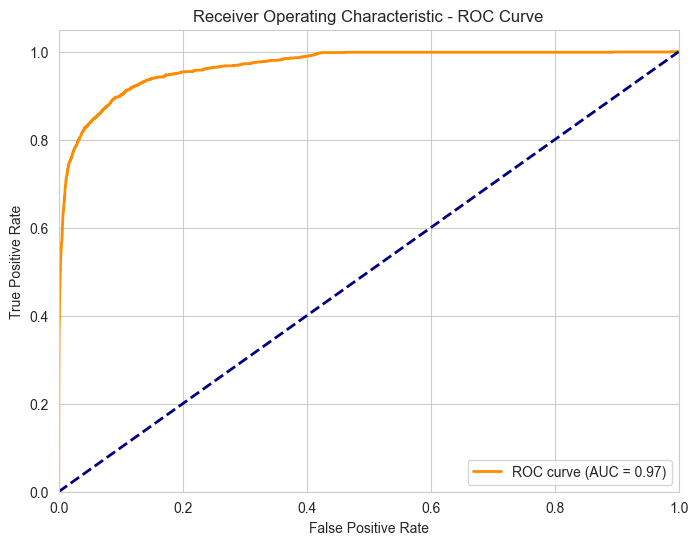

In [158]:
# Get the false positive rate, true positive rate
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

# Plot the ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {auc_roc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')  # Diagonal line
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic - ROC Curve')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

**LightGBM (Default Threshold)**
* Despite a high AUC-ROC, the model performed poorly at predicting fraud accurately due to extreme class imbalance and the default threshold (0.5), which did not suit the problem.

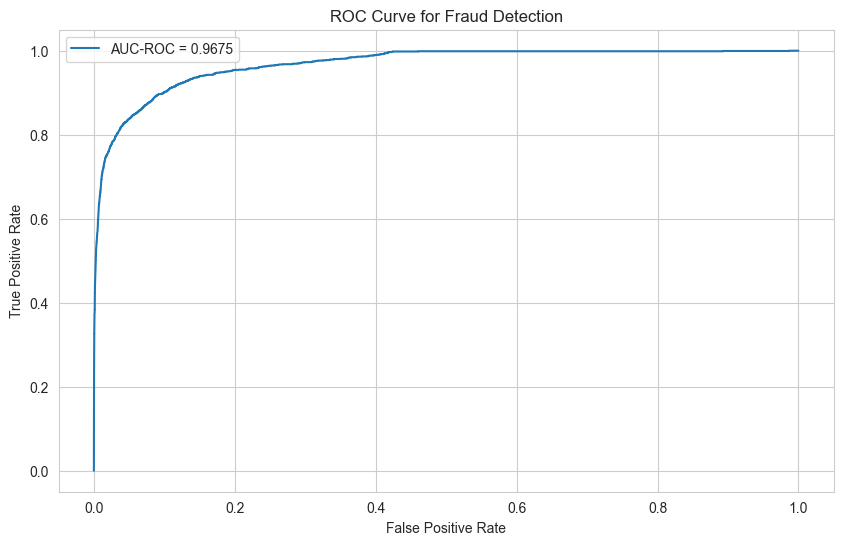

Best Threshold (AUC-ROC): 0.9985

Classification Report with Optimized Threshold (AUC-ROC):
              precision    recall  f1-score   support

   Non-Fraud       1.00      0.91      0.95   1270904
       Fraud       0.01      0.90      0.02      1620

    accuracy                           0.91   1272524
   macro avg       0.51      0.90      0.49   1272524
weighted avg       1.00      0.91      0.95   1272524



In [159]:
# ROC Curve for Optimal Threshold
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = roc_auc_score(y_test, y_prob)

# Plot ROC Curve
plt.figure(figsize=(10, 6))
plt.plot(fpr, tpr, label=f"AUC-ROC = {roc_auc:.4f}")
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve for Fraud Detection')
plt.legend()
plt.show()

# Finding the optimal threshold (closest to top-left)
gmeans = np.sqrt(tpr * (1 - fpr))
ix = np.argmax(gmeans)
best_threshold = thresholds[ix]

print(f"Best Threshold (AUC-ROC): {best_threshold:.4f}")

# Applying the optimal threshold
y_pred_opt = (y_prob >= best_threshold).astype(int)

# Classification Report with Optimized Threshold
print("\nClassification Report with Optimized Threshold (AUC-ROC):")
print(classification_report(y_test, y_pred_opt, target_names=['Non-Fraud', 'Fraud']))

**LightGBM (Optimized Threshold):**
* Adjusting the threshold dramatically improved the model’s ability to detect fraudulent transactions (high recall for fraud), but precision for fraud remained low. This means it correctly catches almost all frauds but produces many false positives.

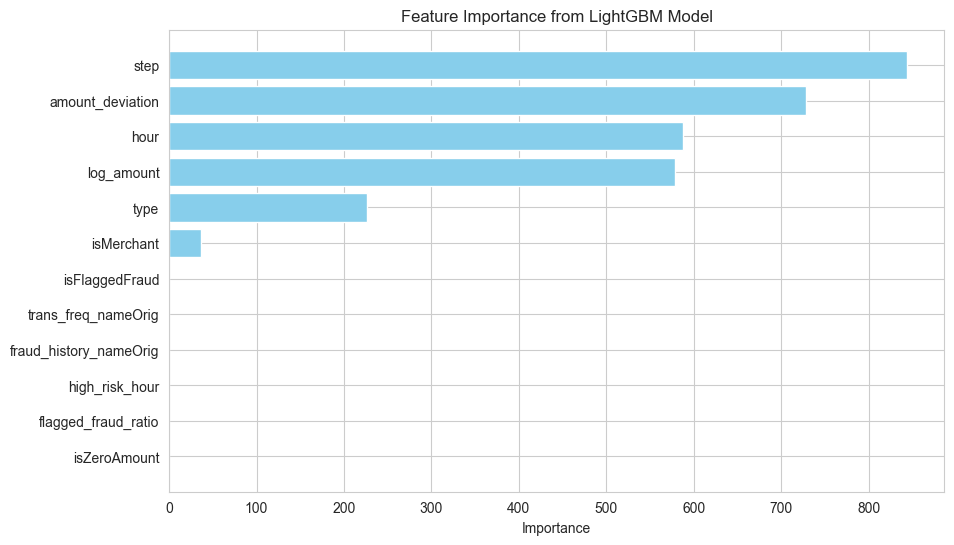

Feature Importance:
                   Feature  Importance
0                     step         844
6         amount_deviation         728
7                     hour         588
11              log_amount         578
1                     type         226
3               isMerchant          36
2           isFlaggedFraud           0
4      trans_freq_nameOrig           0
5   fraud_history_nameOrig           0
8           high_risk_hour           0
9      flagged_fraud_ratio           0
10            isZeroAmount           0


In [162]:
# 3. Feature Importance
feature_importance_df = pd.DataFrame({
    'Feature': X_test.columns,
    'Importance': lgb_model.feature_importances_
})
feature_importance_df = feature_importance_df.sort_values('Importance', ascending=False)

# Plot Feature Importance
plt.figure(figsize=(10, 6))
plt.barh(feature_importance_df['Feature'], feature_importance_df['Importance'], color='skyblue')
plt.xlabel('Importance')
plt.title('Feature Importance from LightGBM Model')
plt.gca().invert_yaxis()
plt.show()

# Print Feature Importance
print("Feature Importance:")
print(feature_importance_df)

0:	test: 0.9367462	best: 0.9367462 (0)	total: 421ms	remaining: 7m
100:	test: 0.9697733	best: 0.9697733 (100)	total: 40.4s	remaining: 5m 59s
200:	test: 0.9717764	best: 0.9717764 (200)	total: 1m 21s	remaining: 5m 23s
300:	test: 0.9726917	best: 0.9727575 (298)	total: 2m 2s	remaining: 4m 45s
400:	test: 0.9733805	best: 0.9734370 (384)	total: 2m 44s	remaining: 4m 6s
500:	test: 0.9735189	best: 0.9735189 (500)	total: 3m 26s	remaining: 3m 25s
600:	test: 0.9730153	best: 0.9735643 (504)	total: 4m 7s	remaining: 2m 44s
700:	test: 0.9729406	best: 0.9735643 (504)	total: 4m 49s	remaining: 2m 3s
800:	test: 0.9727353	best: 0.9735643 (504)	total: 5m 31s	remaining: 1m 22s
900:	test: 0.9726289	best: 0.9735643 (504)	total: 6m 13s	remaining: 41s
999:	test: 0.9730336	best: 0.9735643 (504)	total: 6m 54s	remaining: 0us

bestTest = 0.9735643127
bestIteration = 504

Shrink model to first 505 iterations.


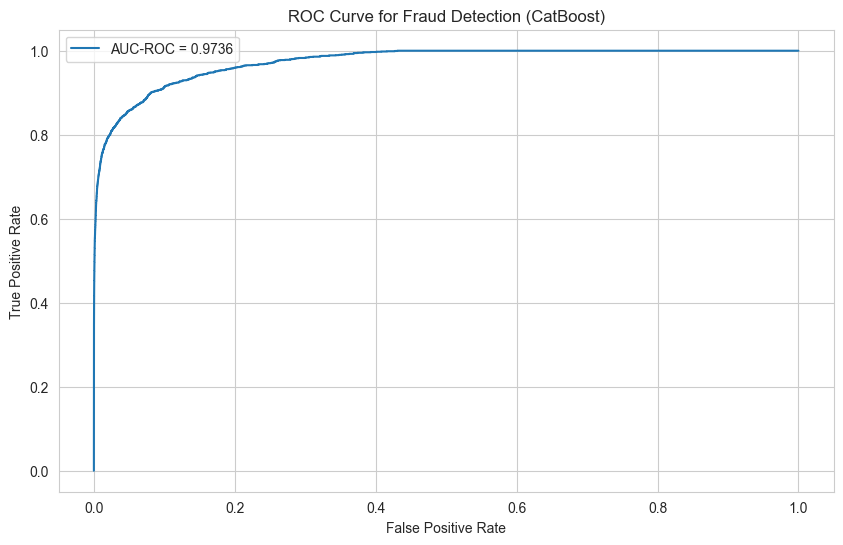

Best Threshold (AUC-ROC): 0.4267

Classification Report with Optimized Threshold (CatBoost):
              precision    recall  f1-score   support

   Non-Fraud       1.00      0.92      0.96   1270904
       Fraud       0.01      0.90      0.03      1620

    accuracy                           0.92   1272524
   macro avg       0.51      0.91      0.49   1272524
weighted avg       1.00      0.92      0.96   1272524



In [160]:
cat_model = cb.CatBoostClassifier(
    iterations=1000,
    learning_rate=0.1,
    depth=6,
    loss_function='Logloss',
    eval_metric='AUC',
    class_weights=[1, len(y_train) / y_train.sum()],
    verbose=100,
    random_state=42
)

cat_model.fit(X_train, y_train, eval_set=(X_test, y_test), verbose=100)

# Predict probabilities
y_prob = cat_model.predict_proba(X_test)[:, 1]

# ROC Curve for Optimal Threshold
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = roc_auc_score(y_test, y_prob)

# Plot ROC Curve
plt.figure(figsize=(10, 6))
plt.plot(fpr, tpr, label=f"AUC-ROC = {roc_auc:.4f}")
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve for Fraud Detection (CatBoost)')
plt.legend()
plt.show()

# Finding the optimal threshold (closest to top-left)
gmeans = np.sqrt(tpr * (1 - fpr))
ix = np.argmax(gmeans)
best_threshold = thresholds[ix]

print(f"Best Threshold (AUC-ROC): {best_threshold:.4f}")

# Applying the optimal threshold
y_pred_opt = (y_prob >= best_threshold).astype(int)

# Classification Report with Optimized Threshold
print("\nClassification Report with Optimized Threshold (CatBoost):")
print(classification_report(y_test, y_pred_opt, target_names=['Non-Fraud', 'Fraud']))

**CatBoost (Optimized Threshold)**
- Achieving a better balance between precision and recall for fraud detection. Despite low precision, it maintains excellent recall, making it a more reliable choice for fraud detection in this highly imbalanced scenario.



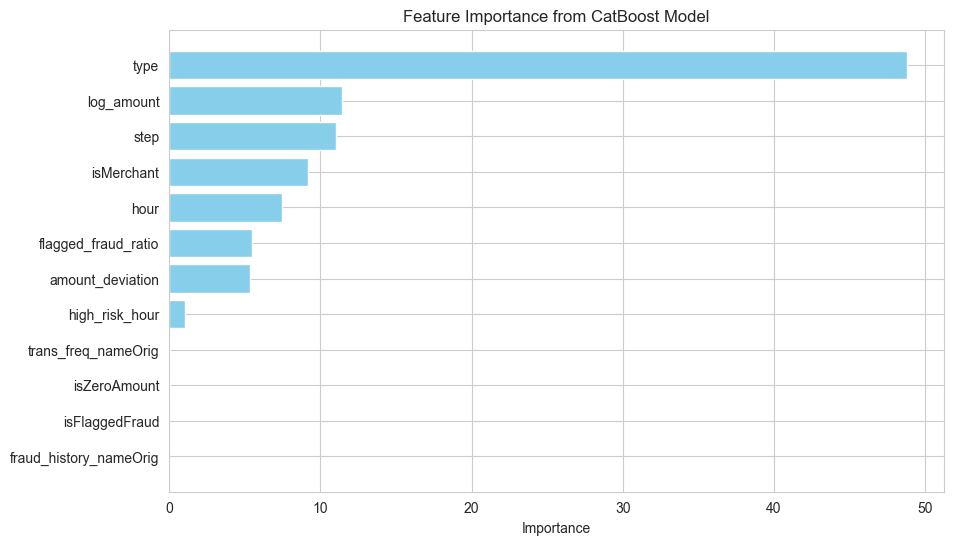

Feature Importance:
                   Feature  Importance
1                     type   48.805423
11              log_amount   11.458324
0                     step   11.030487
3               isMerchant    9.167805
7                     hour    7.497340
9      flagged_fraud_ratio    5.462882
6         amount_deviation    5.334834
8           high_risk_hour    1.065609
4      trans_freq_nameOrig    0.089786
10            isZeroAmount    0.087510
2           isFlaggedFraud    0.000000
5   fraud_history_nameOrig    0.000000


In [161]:
# 3. Feature Importance
feature_importance_df = pd.DataFrame({
    'Feature': X_test.columns,
    'Importance': cat_model.feature_importances_
})
feature_importance_df = feature_importance_df.sort_values('Importance', ascending=False)

# Plot Feature Importance
plt.figure(figsize=(10, 6))
plt.barh(feature_importance_df['Feature'], feature_importance_df['Importance'], color='skyblue')
plt.xlabel('Importance')
plt.title('Feature Importance from CatBoost Model')
plt.gca().invert_yaxis()
plt.show()

# Print Feature Importance
print("Feature Importance:")
print(feature_importance_df)

**Key Takeaways**
- CatBoost performed slightly better.

- Threshold optimization significantly improved both models' performance by improving recall without severely sacrificing precision.

- Both models can be further fine-tuned with hyperparameter optimization for potentially better results.

# Conclusion

In this project, we worked on detecting fraudulent transactions in mobile money data. We started by analyzing the data to understand patterns of fraud and built models to predict fraudulent transactions.

- **Key Findings:**
    - Fraudulent Transactions: Fraud mainly occurred in TRANSFER and CASH_OUT transaction types, with higher transaction amounts compared to non-fraudulent ones.

    - Merchant Transactions: Fraud was only found in non-Merchant transactions, making the isMerchant feature important for fraud detection.

    - Class Imbalance: Fraud transactions were much fewer than non-fraud transactions, which made it harder for the models to identify fraud.

- **Model Results:**
    - LightGBM: Good performance with an AUC-ROC of 0.968, but the model struggled with precision for fraud detection.

    - CatBoost: Performed better with an AUC-ROC of 0.973 and showed higher recall for detecting fraud, but still had low precision.

**Conclusion:**
* CatBoost is a better model for detecting fraud because it has a higher recall, meaning it catches more fraud cases,But models had issues with class imbalance

Overall, this project shows that while fraud detection in imbalanced data is challenging, models like CatBoost can help in identifying fraudulent transactions effectively.